# Falcon-H1-Tiny-90M: Visualizing Tokens In and Tokens Out

This notebook demonstrates how the **tiiuae/Falcon-H1-Tiny-90M-Instruct** language model
processes text.

- **Tokens In**: The text is split into subword tokens by a BPE tokenizer, and each token
  is mapped to a learned embedding vector.
- **Tokens Out**: After passing through 24 hybrid Transformer + Mamba layers, each token
  position has a contextual embedding and a logit distribution over the vocabulary.

We visualize both sides to build intuition about how language models tokenize and
process text.

In [1]:
# Install dependencies (uncomment if needed)
# !pip install torch transformers matplotlib scikit-learn

In [2]:
import torch
import torch.nn.functional as F

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib

    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

## 1. Load the Model and Tokenizer

In [3]:
model_id = "tiiuae/Falcon-H1-Tiny-90M-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32

print(f"Using device: {device}, dtype: {dtype}")

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=dtype).to(device)
model.eval()

print(f"Model loaded: {model_id}")
print(f"Architecture: Hybrid Transformer + Mamba (falcon_h1)")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Hidden dim: {model.config.hidden_size}")
print(f"Layers: {model.config.num_hidden_layers}")

Using device: cpu, dtype: torch.float32


The fast path is not available because one of `(selective_state_update, causal_conv1d_fn, causal_conv1d_update)` is None. Falling back to the naive implementation. To install follow https://github.com/state-spaces/mamba/#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/386 [00:00<?, ?it/s]

Model loaded: tiiuae/Falcon-H1-Tiny-90M-Instruct
Architecture: Hybrid Transformer + Mamba (falcon_h1)
Parameters: 91.1M
Vocab size: 32,768
Hidden dim: 512
Layers: 24


## 2. Choose an Input Text

In [4]:
text = "The quick brown fox jumps over the lazy dog."

inputs = tokenizer(text, return_tensors="pt").to(device)
input_ids = inputs["input_ids"]
num_tokens = input_ids.shape[1]

print(f"Input text:  {repr(text)}")
print(f"Num tokens:  {num_tokens}")

Input text:  'The quick brown fox jumps over the lazy dog.'
Num tokens:  11


## 3. Tokens In -- Tokenization and Embeddings

The tokenizer splits text into **subword tokens** using Byte-Pair Encoding (BPE).
Each token is assigned an integer ID that indexes into a learned embedding table
of shape `(vocab_size, hidden_dim)` = `(32768, 512)`.

This is the input representation the model actually sees.

In [5]:
# Decode each token individually to see the subword pieces
token_ids = input_ids[0].tolist()
token_strings = [tokenizer.decode([t]) for t in token_ids]

print("=" * 60)
print("TOKENS IN")
print("=" * 60)
print(f"{'Pos':>4}  {'Token ID':>8}  {'Token String'}")
print("-" * 40)
for i, (tid, tstr) in enumerate(zip(token_ids, token_strings)):
    print(f"{i:>4}  {tid:>8}  {repr(tstr)}")
print()
print(f"Total: {num_tokens} tokens from {len(text)} characters")
print(f"Average: {len(text) / num_tokens:.1f} characters per token")

TOKENS IN
 Pos  Token ID  Token String
----------------------------------------
   0      1243  'The'
   1      6392  ' quick'
   2     13887  ' brown'
   3     31479  ' fox'
   4      1133  ' j'
   5     13056  'umps'
   6      1356  ' over'
   7       784  ' the'
   8     17620  ' lazy'
   9      7281  ' dog'
  10       537  '.'

Total: 11 tokens from 44 characters
Average: 4.0 characters per token


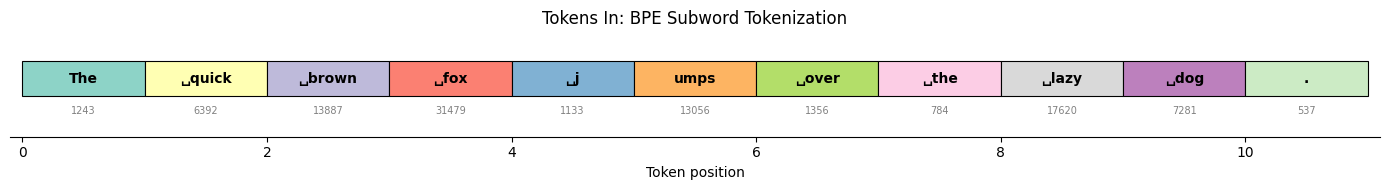

In [6]:
# Visualize the tokenization as a color-coded bar
fig, ax = plt.subplots(figsize=(max(14, num_tokens * 1.2), 2.0))

cmap = plt.cm.Set3
colors = [cmap(i / num_tokens) for i in range(num_tokens)]

for i, (tstr, color) in enumerate(zip(token_strings, colors)):
    ax.barh(0, 1, left=i, color=color, edgecolor="black", linewidth=0.8, height=0.6)
    label = tstr.replace(" ", "\u2423")  # display space as visible character
    ax.text(i + 0.5, 0, label, ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(
        i + 0.5,
        -0.55,
        str(token_ids[i]),
        ha="center",
        va="center",
        fontsize=7,
        color="gray",
    )

ax.set_xlim(-0.1, num_tokens + 0.1)
ax.set_ylim(-1.0, 0.8)
ax.set_yticks([])
ax.set_xlabel("Token position")
ax.set_title("Tokens In: BPE Subword Tokenization")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
# Look at the input embedding vectors
embedding_layer = model.model.embed_tokens
input_embeddings = embedding_layer(input_ids).detach().cpu().float()
embed_dim = input_embeddings.shape[-1]

print(f"Embedding table shape: {embedding_layer.weight.shape}")
print(f"  = {embedding_layer.weight.shape[0]:,} vocab entries x {embed_dim}d")
print()
print(f"Input embeddings shape: {tuple(input_embeddings.shape)}")
print(f"  = {num_tokens} tokens x {embed_dim}d")
print()
print("These are static lookup embeddings (no context yet).")

Embedding table shape: torch.Size([32768, 512])
  = 32,768 vocab entries x 512d

Input embeddings shape: (1, 11, 512)
  = 11 tokens x 512d

These are static lookup embeddings (no context yet).


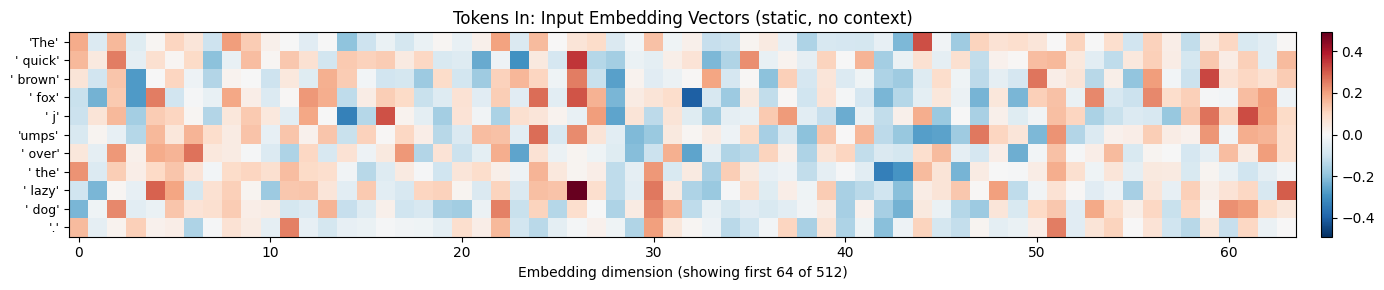

In [8]:
# Visualize input embeddings as a heatmap
fig, ax = plt.subplots(figsize=(14, 3))
emb_np = input_embeddings[0].numpy()

# Show first 64 dimensions for readability
show_dims = min(64, embed_dim)
im = ax.imshow(
    emb_np[:, :show_dims],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.abs(emb_np[:, :show_dims]).max(),
    vmax=np.abs(emb_np[:, :show_dims]).max(),
)
ax.set_yticks(range(num_tokens))
ax.set_yticklabels([repr(s) for s in token_strings], fontsize=9)
ax.set_xlabel(f"Embedding dimension (showing first {show_dims} of {embed_dim})")
ax.set_title("Tokens In: Input Embedding Vectors (static, no context)")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()

## 4. Tokens Out -- Model Output

We pass the tokens through all 24 layers of the hybrid Transformer + Mamba model.
Each token position produces:

- A **contextual hidden state** (512d) -- the token's representation after seeing
  all preceding context.
- **Logits** over the full vocabulary (32,768 entries) -- the model's prediction for
  what token comes next at each position.

In [9]:
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

logits = outputs.logits.detach().cpu().float()  # (1, num_tokens, vocab_size)
hidden_states = [h.detach().cpu().float() for h in outputs.hidden_states]
final_hidden = hidden_states[-1]  # (1, num_tokens, hidden_dim)

print("=" * 60)
print("TOKENS OUT")
print("=" * 60)
print(
    f"Hidden states: {len(hidden_states)} layers (embedding + {len(hidden_states) - 1} transformer)"
)
print(
    f"  Each layer: {tuple(final_hidden.shape)} = {num_tokens} tokens x {final_hidden.shape[-1]}d"
)
print(
    f"Logits: {tuple(logits.shape)} = {num_tokens} tokens x {logits.shape[-1]:,} vocab"
)
print()
print("=" * 60)
print("TOKENS IN vs TOKENS OUT")
print("=" * 60)
print(f"  IN:  {num_tokens} tokens, each {embed_dim}d  (static embeddings)")
print(
    f"  OUT: {num_tokens} tokens, each {final_hidden.shape[-1]}d  (contextual embeddings)"
)
print(f"       + logits over {logits.shape[-1]:,} vocabulary entries per token")
print()
print(f"  The model transforms static {embed_dim}d embeddings")
print(f"  into context-dependent {final_hidden.shape[-1]}d representations.")

FalconH1 requires an initialized `FalconHybridMambaAttentionDynamicCache` to return a cache. None was provided, so no cache will be returned.


TOKENS OUT
Hidden states: 25 layers (embedding + 24 transformer)
  Each layer: (1, 11, 512) = 11 tokens x 512d
Logits: (1, 11, 32768) = 11 tokens x 32,768 vocab

TOKENS IN vs TOKENS OUT
  IN:  11 tokens, each 512d  (static embeddings)
  OUT: 11 tokens, each 512d  (contextual embeddings)
       + logits over 32,768 vocabulary entries per token

  The model transforms static 512d embeddings
  into context-dependent 512d representations.


In [10]:
# Show next-token predictions at each position
probs = torch.softmax(logits[0], dim=-1)
top_k = 5

print("Next-token predictions at each position:")
print("=" * 70)
for i in range(num_tokens):
    top_probs, top_ids = probs[i].topk(top_k)
    preds = ", ".join(
        f"{repr(tokenizer.decode([tid.item()]))}({p:.0%})"
        for tid, p in zip(top_ids, top_probs)
    )
    actual_next = repr(token_strings[i + 1]) if i + 1 < num_tokens else "<end>"
    print(f"  After {repr(token_strings[i]):>12} -> top-{top_k}: {preds}")
    print(f"{'':>20}    actual next: {actual_next}")

Next-token predictions at each position:
  After        'The' -> top-5: ' '(4%), ' D'(1%), ' B'(1%), ' C'(1%), ' A'(0%)
                        actual next: ' quick'
  After     ' quick' -> top-5: ' and'(22%), ' way'(5%), 'sort'(4%), ','(3%), '-'(3%)
                        actual next: ' brown'
  After     ' brown' -> top-5: ','(6%), ' color'(3%), '-'(3%), '.'(3%), ' spots'(2%)
                        actual next: ' fox'
  After       ' fox' -> top-5: ' turned'(11%), ' j'(6%), '.'(5%), ','(5%), ' looked'(3%)
                        actual next: ' j'
  After         ' j' -> top-5: 'umps'(60%), 'umped'(35%), 'acket'(1%), 'umper'(1%), 'og'(1%)
                        actual next: 'umps'
  After       'umps' -> top-5: ' over'(49%), ' onto'(4%), ' into'(4%), ' up'(3%), ' to'(2%)
                        actual next: ' over'
  After      ' over' -> top-5: ' the'(55%), ' a'(11%), ' to'(5%), ' un'(2%), ' b'(1%)
                        actual next: ' the'
  After       ' the' -> top-5: ' lazy'(

## 5. Visualize Output Token Embeddings

We use PCA to project the high-dimensional output embeddings down to 2D and 3D,
showing how the model groups tokens by meaning after processing.

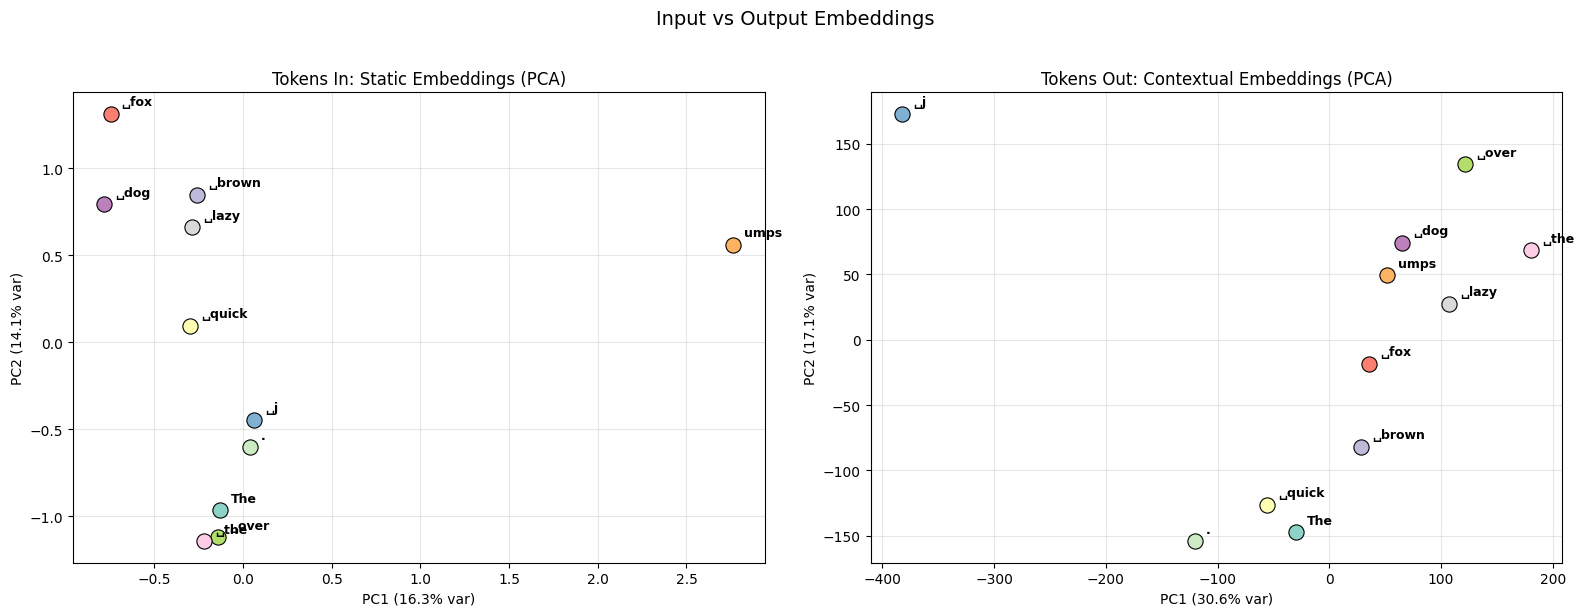

In [11]:
from sklearn.decomposition import PCA

# Compare input (static) vs output (contextual) embeddings in 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (embs, title) in zip(
    axes,
    [
        (input_embeddings[0].numpy(), "Tokens In: Static Embeddings (PCA)"),
        (final_hidden[0].numpy(), "Tokens Out: Contextual Embeddings (PCA)"),
    ],
):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(embs)
    var = pca.explained_variance_ratio_

    cmap = plt.cm.Set3
    for i in range(num_tokens):
        ax.scatter(
            coords[i, 0],
            coords[i, 1],
            c=[cmap(i / num_tokens)],
            s=120,
            edgecolors="black",
            linewidth=0.8,
            zorder=3,
        )
        label = token_strings[i].replace(" ", "\u2423")
        ax.annotate(
            label,
            (coords[i, 0], coords[i, 1]),
            textcoords="offset points",
            xytext=(8, 6),
            fontsize=9,
            fontweight="bold",
        )

    ax.set_xlabel(f"PC1 ({var[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({var[1]:.1%} var)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("Input vs Output Embeddings", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Token-level Cosine Similarity

Cosine similarity between output embeddings reveals which tokens the model considers
semantically related after processing the full context.

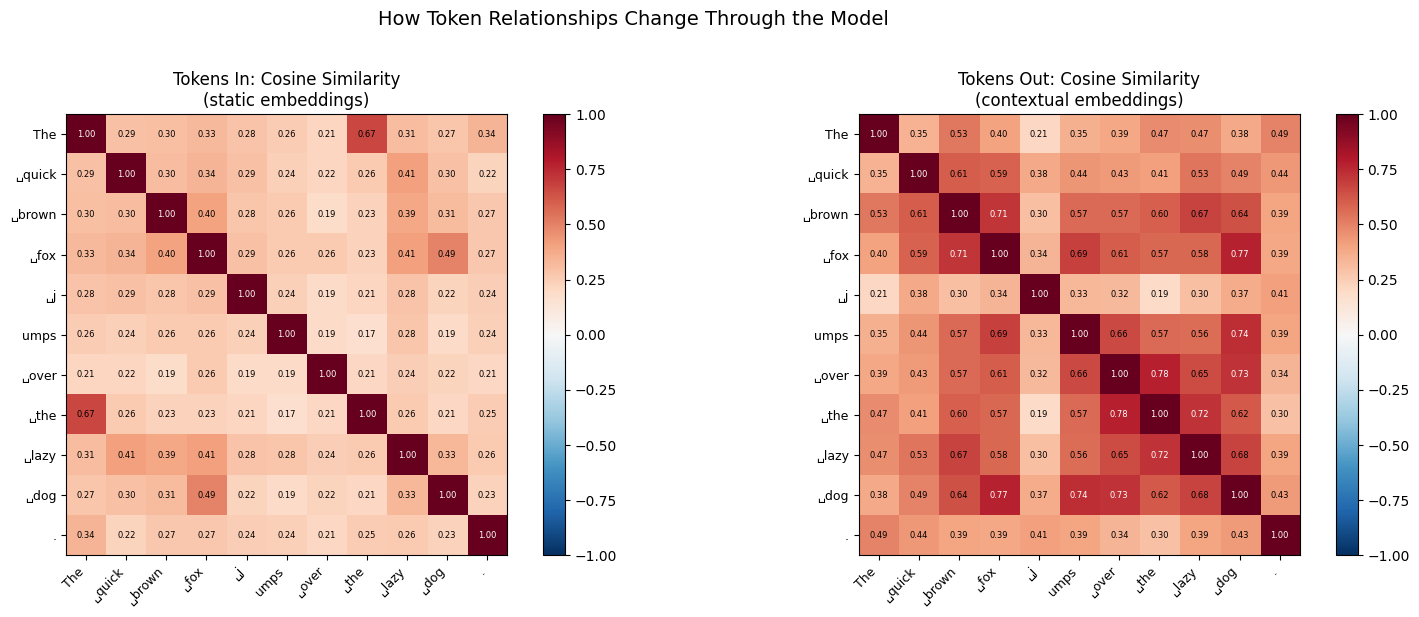

In [12]:
# Compute cosine similarity matrices for input vs output
in_embs = input_embeddings[0]  # (num_tokens, 512)
out_embs = final_hidden[0]  # (num_tokens, 512)

in_norm = F.normalize(in_embs, dim=-1)
out_norm = F.normalize(out_embs, dim=-1)

in_sim = (in_norm @ in_norm.T).numpy()
out_sim = (out_norm @ out_norm.T).numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = [s.replace(" ", "\u2423") for s in token_strings]

for ax, sim, title in zip(
    axes,
    [in_sim, out_sim],
    [
        "Tokens In: Cosine Similarity\n(static embeddings)",
        "Tokens Out: Cosine Similarity\n(contextual embeddings)",
    ],
):
    im = ax.imshow(sim, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(num_tokens))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(num_tokens))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Annotate each cell with the value
    for i in range(num_tokens):
        for j in range(num_tokens):
            ax.text(
                j,
                i,
                f"{sim[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=6,
                color="black" if abs(sim[i, j]) < 0.7 else "white",
            )

plt.suptitle("How Token Relationships Change Through the Model", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Layer-by-Layer Evolution

Watch how token representations evolve as they pass through the 24 layers of the model.
We measure how much each layer changes the representations (layer-wise cosine distance
from the previous layer).

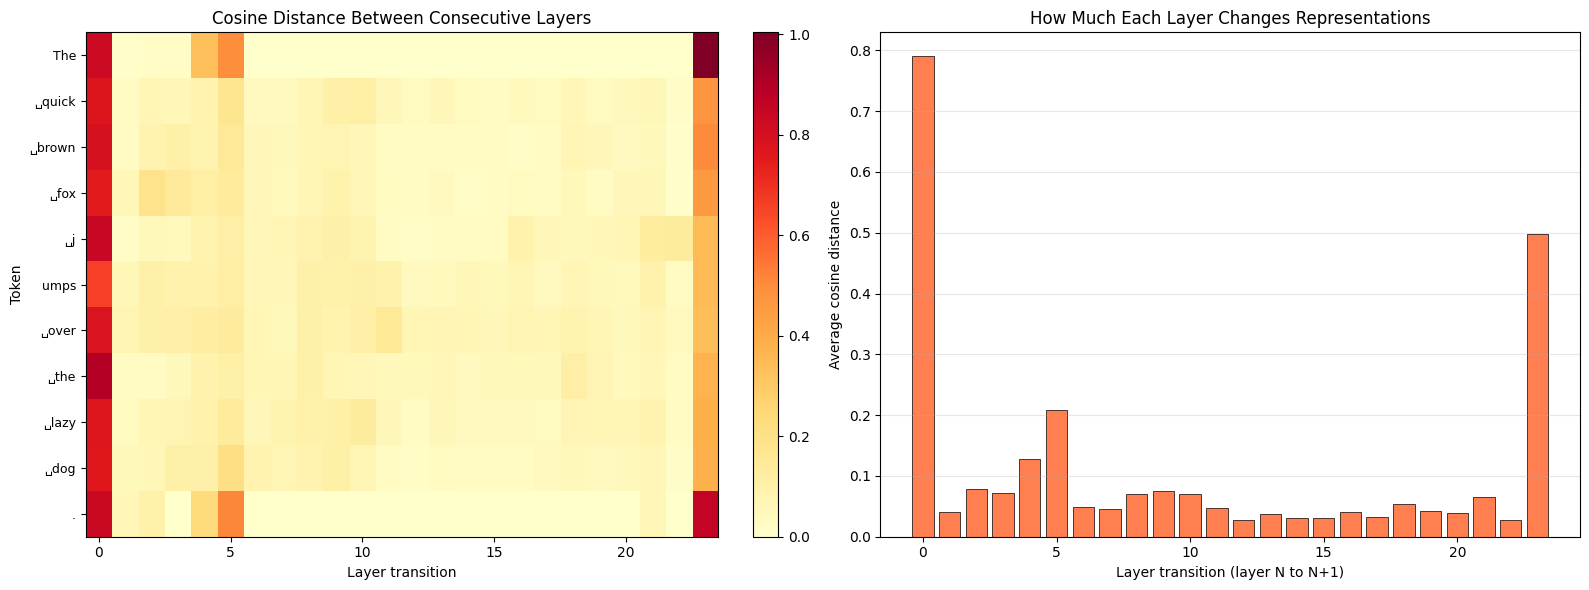

In [13]:
# Compute cosine similarity between consecutive layers for each token
n_layers = len(hidden_states)
layer_changes = np.zeros((n_layers - 1, num_tokens))

for layer_idx in range(1, n_layers):
    prev = F.normalize(hidden_states[layer_idx - 1][0], dim=-1)
    curr = F.normalize(hidden_states[layer_idx][0], dim=-1)
    # cosine distance = 1 - cosine_similarity
    cos_dist = 1.0 - (prev * curr).sum(dim=-1).numpy()
    layer_changes[layer_idx - 1] = cos_dist

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: heatmap of per-token per-layer change
im = axes[0].imshow(layer_changes.T, aspect="auto", cmap="YlOrRd")
axes[0].set_xlabel("Layer transition")
axes[0].set_ylabel("Token")
axes[0].set_yticks(range(num_tokens))
axes[0].set_yticklabels(labels, fontsize=9)
axes[0].set_title("Cosine Distance Between Consecutive Layers")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Right: average change per layer
avg_change = layer_changes.mean(axis=1)
axes[1].bar(
    range(len(avg_change)), avg_change, color="coral", edgecolor="black", linewidth=0.5
)
axes[1].set_xlabel("Layer transition (layer N to N+1)")
axes[1].set_ylabel("Average cosine distance")
axes[1].set_title("How Much Each Layer Changes Representations")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 8. Output Logit Distribution

The final output at each token position is a probability distribution over the
entire vocabulary. This is what the model uses to predict the next token.

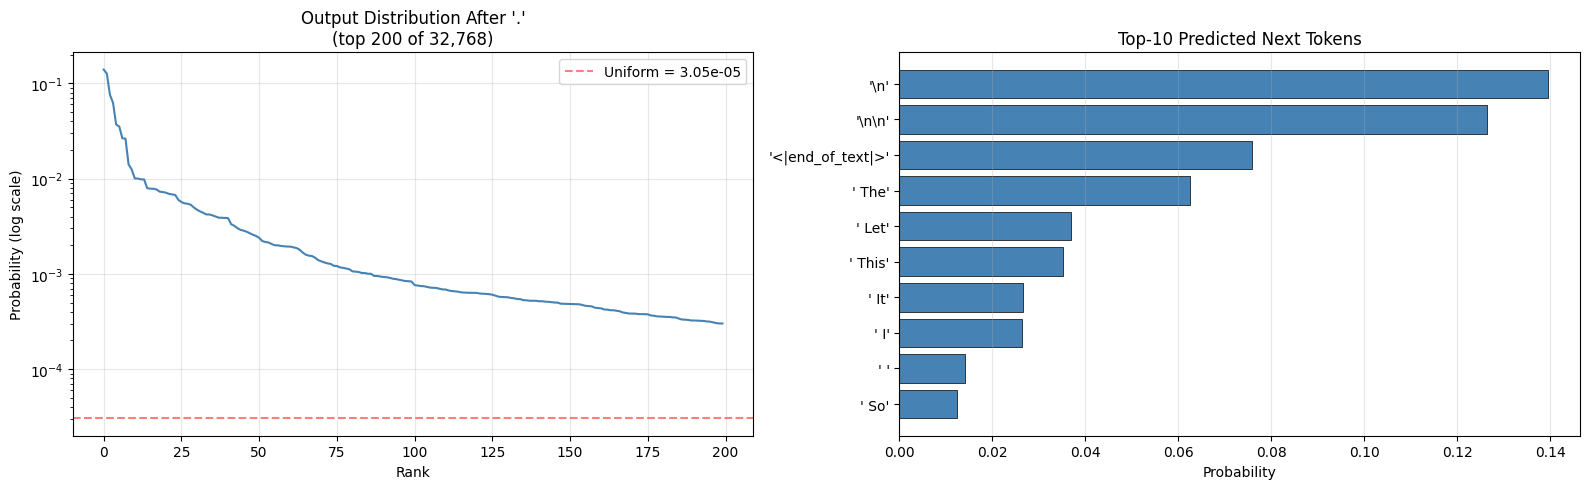

In [14]:
# Visualize the probability distribution at the last token position
last_pos = num_tokens - 1
last_probs = torch.softmax(logits[0, last_pos], dim=-1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: full distribution (sorted)
sorted_probs = np.sort(last_probs)[::-1]
axes[0].semilogy(sorted_probs[:200], color="steelblue", linewidth=1.5)
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Probability (log scale)")
axes[0].set_title(
    f"Output Distribution After {repr(token_strings[last_pos])}\n(top 200 of {len(last_probs):,})"
)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(
    y=1 / len(last_probs),
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Uniform = {1 / len(last_probs):.2e}",
)
axes[0].legend()

# Right: top-10 tokens as a bar chart
top_n = 10
top_probs_vals, top_ids = torch.tensor(last_probs).topk(top_n)
top_labels = [repr(tokenizer.decode([tid.item()])) for tid in top_ids]

y_pos = range(top_n - 1, -1, -1)
axes[1].barh(
    list(y_pos),
    top_probs_vals.numpy(),
    color="steelblue",
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(top_labels, fontsize=10)
axes[1].set_xlabel("Probability")
axes[1].set_title(f"Top-{top_n} Predicted Next Tokens")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 9. Summary

| | Tokens In | Tokens Out |
|---|---|---|
| **What** | Subword pieces (BPE) | Contextual embeddings + logits |
| **Count** | N tokens from input text | Same N positions |
| **Dimensionality** | 512d static embedding per token | 512d contextual embedding + 32,768 logits |
| **Meaning** | Identity of each subword (no context) | Context-dependent semantic representation |
| **Produced by** | Tokenizer + embedding lookup table | 24 hybrid Transformer + Mamba layers |
| **Key difference** | Same word always gets the same vector | Same word gets different vectors depending on surrounding context |